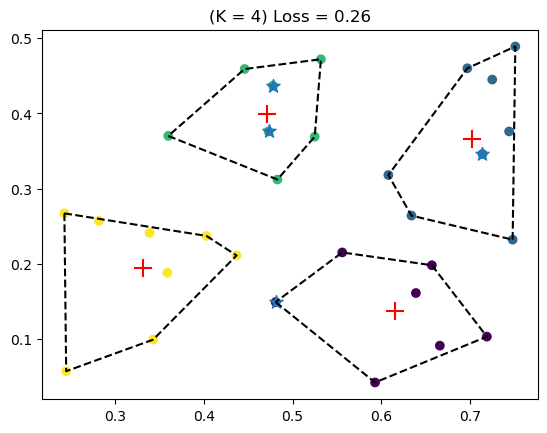

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

class KMeans:
    def __init__(self,k,max_iter = 10):
        """
        K-means聚类算法
        参数:
        k: 聚类簇数
        max_iter: 最大迭代次数
        """
        self.k = k
        self.max_iter = max_iter
        self.centroids  = None # 聚类中心
        self.labels = None # 聚类标签

    def calculate_distance(self,x,μ):
        """计算样本点与聚类中心之间的欧氏距离"""
        return np.sqrt(np.sum((x - μ)**2))
    
    def find_closest_centroid(self,distances):
        """返回最近的聚类中心索引"""
        return np.argmin(distances)
    
    def fit(self,data):
        """训练"""
        self.labels = np.zeros(len(data))
        # 随机选择K个样本点作为初始聚类中心
        rand_index = np.random.choice(len(data),self.k,replace = False)
        # rand_index = [5,11,23] # 与书上保持一样
        self.centroids = data[rand_index]
        self.init_centroids = self.centroids.copy()
        # 迭代寻找最优解
        for i in range(self.max_iter):
            # E-step
            for j in range(len(data)):
                distances = []
                for k in range(self.k):
                    d = self.calculate_distance(data[j],self.centroids[k])
                    distances.append(d)
                # 找到最近的聚类中心
                closest_centroid = self.find_closest_centroid(distances)
                # 更新样本点的标签
                self.labels[j] = closest_centroid
            # M-step
            for j in range(self.k):
                # 更新聚类中心
                new_centroids = np.mean(data[self.labels == j],axis = 0)
                self.centroids[j] = new_centroids
    
    def Loss(self):
        """计算损失 公式(9.24)"""
        Loss = 0
        for i in range(self.k):
            points = data[self.labels == i]
            Loss += np.sum((points - self.centroids[i])**2)
        return Loss

if __name__ == '__main__':
    # 加载数据
    data = np.loadtxt('../Data/4.0.csv',dtype = float,delimiter = ',')
    # 实例化KMeans
    kmeans = KMeans(k = 4,max_iter = 4)
    # 训练
    kmeans.fit(data)
    loss = kmeans.Loss()
    # 可视化
    plt.scatter(data[:,0],data[:,1],c = kmeans.labels)
    plt.scatter(kmeans.init_centroids[:,0],kmeans.init_centroids[:,1],marker = '*',s=100)
    plt.scatter(kmeans.centroids[:,0],kmeans.centroids[:,1],marker = '+',s = 150,c = 'r')
    plt.title('(K = 4) Loss = %.2f'%loss)
    # 画出每一个簇的凸包
    for i in range(kmeans.k):
        points = data[kmeans.labels == i]
        hull = ConvexHull(points).vertices.tolist()
        hull.append(hull[0])    
        plt.plot(points[hull,0],points[hull,1],'k--')
    plt.show()

    